# EDA — Stationnement voie publique Paris
Analyse exploratoire des emplacements de stationnement par arrondissement.

In [1]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

with open('../brute/indicateur-Score-accessibilité-mobilité/stationnement-voie-publique-emplacements.json', encoding='utf-8') as f:
    data = json.load(f)

df_raw = pd.DataFrame(data['records'])
print(f'Shape brute : {df_raw.shape}')
df_raw.head(3)

Shape brute : (64925, 43)


,regpri,regpar,typsta,arrond,placal,plarel,zoneres,locsta,numvoie,typevoie,...,numiris,zoneasp,stv,prefet,mtlast_edit_date_field,datereleve,n_voieadd,n_voieadf,geo_shape,geo_point_2d
0,2 ROUES,Vélos,Epi,1,26,26,1E,Trottoir,35.0,PL,...,None,01Z2,STV Centre,None,2021-06-11,2020-08-02,2.0,0,"{'type': 'Feature', 'geometry': {'coordinates'...","{'lon': 2.3450719630286954, 'lat': 48.86147187..."
1,2 ROUES,Vélos,Bataille,1,10,10,1E,Chaussée,6.0,RUE,...,None,01Z2,STV Centre,None,2022-07-27,2022-07-18,1.0,7,"{'type': 'Feature', 'geometry': {'coordinates'...","{'lon': 2.3419430685371116, 'lat': 48.86040828..."
2,LOCATION,Vélib',Bataille,1,28,28,1E,Chaussée,5.0,RUE,...,None,01Z2,STV Centre,None,2022-07-27,2022-07-18,1.0,7,"{'type': 'Feature', 'geometry': {'coordinates'...","{'lon': 2.341396714339949, 'lat': 48.860294343..."


## 1. Vue générale

In [2]:
print('Colonnes :')
print(df_raw.columns.tolist())
print(f'\nLignes  : {len(df_raw):,}')
print(f'Colonnes: {df_raw.shape[1]}')

Colonnes :
['regpri', 'regpar', 'typsta', 'arrond', 'placal', 'plarel', 'zoneres', 'locsta', 'numvoie', 'typevoie', 'nomvoie', 'compnumvoie', 'locnum', 'parite', 'lon', 'lar', 'surface_calculee', 'signhor', 'signvert', 'confsign', 'typemob', 'nummob', 'plage_hor1_debut', 'plage_hor1_fin', 'plage_hor2_debut', 'plage_hor2_fin', 'plage_hor3_debut', 'plage_hor3_fin', 'id', 'id_old', 'c_voie_vp', 'n_sq_tv', 'numilot', 'numiris', 'zoneasp', 'stv', 'prefet', 'mtlast_edit_date_field', 'datereleve', 'n_voieadd', 'n_voieadf', 'geo_shape', 'geo_point_2d']

Lignes  : 64,925
Colonnes: 43


## 2. Valeurs manquantes

Colonnes avec valeurs manquantes :
prefet              64925
numilot             64924
numiris             64924
plage_hor3_fin      64873
plage_hor3_debut    64872
plage_hor2_fin      64302
plage_hor2_debut    64301
plage_hor1_fin      64146
plage_hor1_debut    64146
compnumvoie         58812
id                  42749
typemob             36614
locnum              24564
numvoie             22676
id_old              22177
nummob               7585
parite                 16
n_voieadd               3
confsign                1
dtype: int64


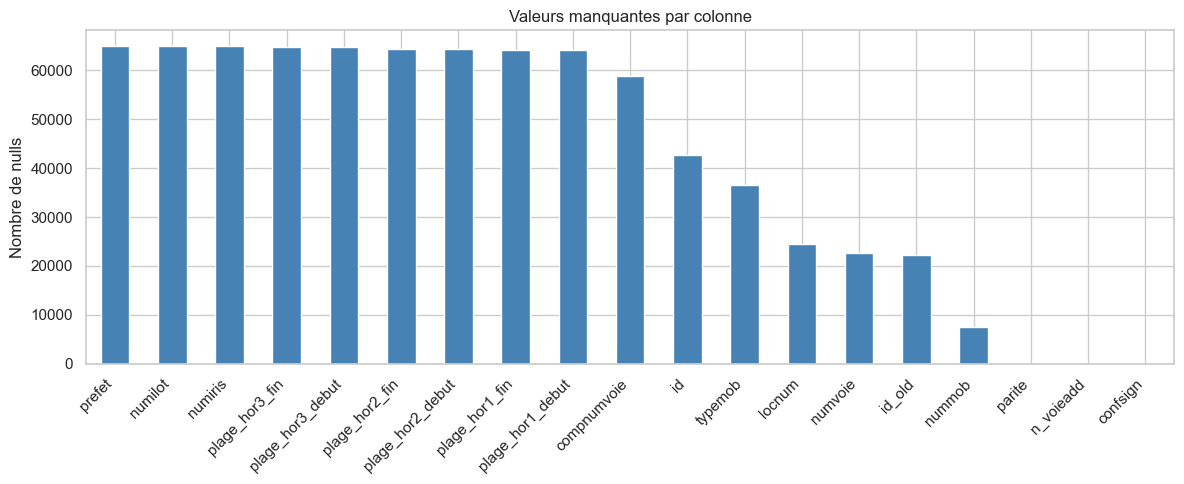

In [3]:
nulls = df_raw.isnull().sum()
nulls = nulls[nulls > 0].sort_values(ascending=False)
print('Colonnes avec valeurs manquantes :')
print(nulls)

ax = nulls.plot(kind='bar', color='steelblue')
ax.set_title('Valeurs manquantes par colonne')
ax.set_ylabel('Nombre de nulls')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 3. Doublons

In [4]:
doublons = df_raw.duplicated(subset=['id']).sum()
print(f'Doublons sur id : {doublons:,}')
print(f'Lignes uniques  : {len(df_raw) - doublons:,}')

Doublons sur id : 42,748
Lignes uniques  : 22,177


## 4. Distribution par arrondissement

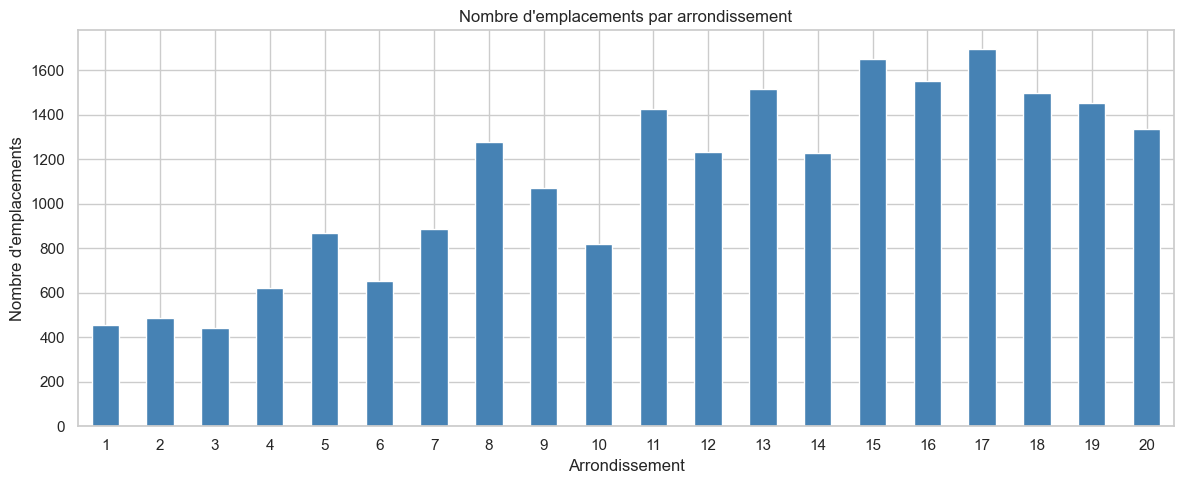

arrond
1      454
2      486
3      441
4      620
5      867
6      651
7      889
8     1280
9     1073
10     820
11    1426
12    1232
13    1516
14    1229
15    1653
16    1553
17    1695
18    1500
19    1455
20    1337
Name: count, dtype: int64


In [5]:
df = df_raw.drop_duplicates(subset=['id']).copy()

arr_counts = df['arrond'].value_counts().sort_index()
ax = arr_counts.plot(kind='bar', color='steelblue')
ax.set_title('Nombre d\'emplacements par arrondissement')
ax.set_xlabel('Arrondissement')
ax.set_ylabel('Nombre d\'emplacements')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
print(arr_counts)

## 5. Distribution des régimes de priorité

regpri
2 ROUES           12309
PAYANT MIXTE       3423
LIVRAISON          2476
GIG/GIC            1503
AUTRE REGIME       1126
LOCATION            470
PAYANT ROTATIF      451
GRATUIT             218
ELECTRIQUE          157
AUTOCAR              44
Name: count, dtype: int64


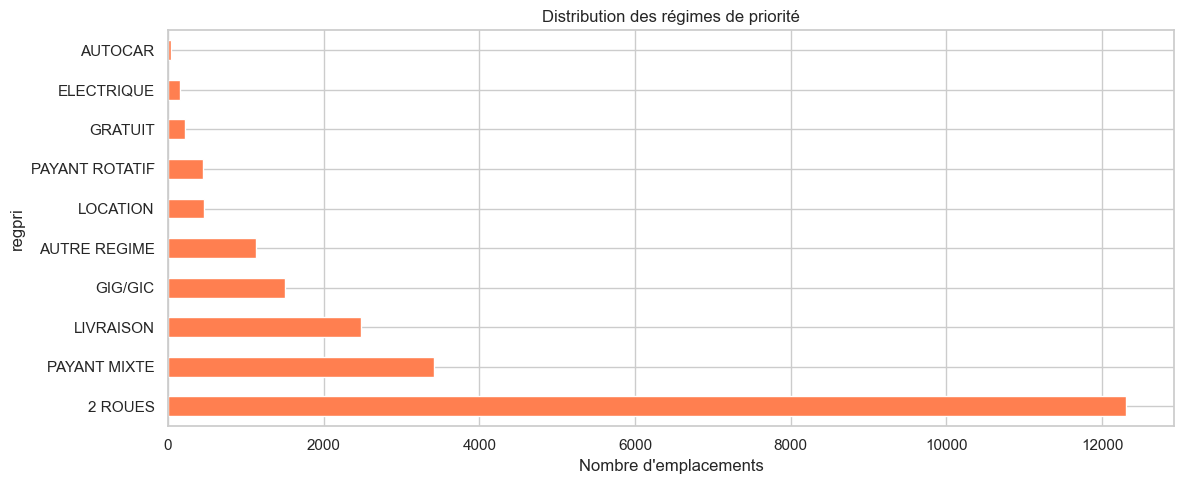

In [6]:
regime_counts = df['regpri'].value_counts()
print(regime_counts)

ax = regime_counts.plot(kind='barh', color='coral')
ax.set_title('Distribution des régimes de priorité')
ax.set_xlabel('Nombre d\'emplacements')
plt.tight_layout()
plt.show()

## 6. Places relevées par arrondissement

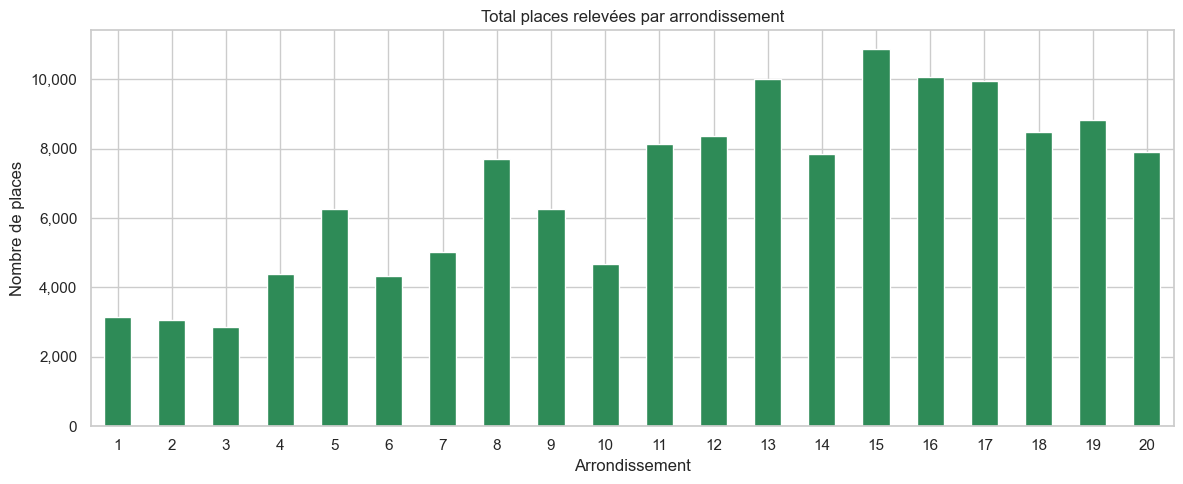

arrond
1      3137
2      3055
3      2874
4      4384
5      6264
6      4330
7      5026
8      7698
9      6272
10     4665
11     8147
12     8360
13    10004
14     7849
15    10864
16    10077
17     9950
18     8472
19     8821
20     7910
Name: plarel, dtype: int64


In [7]:
df['plarel'] = pd.to_numeric(df['plarel'], errors='coerce')

places_arr = df.groupby('arrond')['plarel'].sum().sort_index()
ax = places_arr.plot(kind='bar', color='seagreen')
ax.set_title('Total places relevées par arrondissement')
ax.set_xlabel('Arrondissement')
ax.set_ylabel('Nombre de places')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
print(places_arr)

## 7. Régime par arrondissement (heatmap)

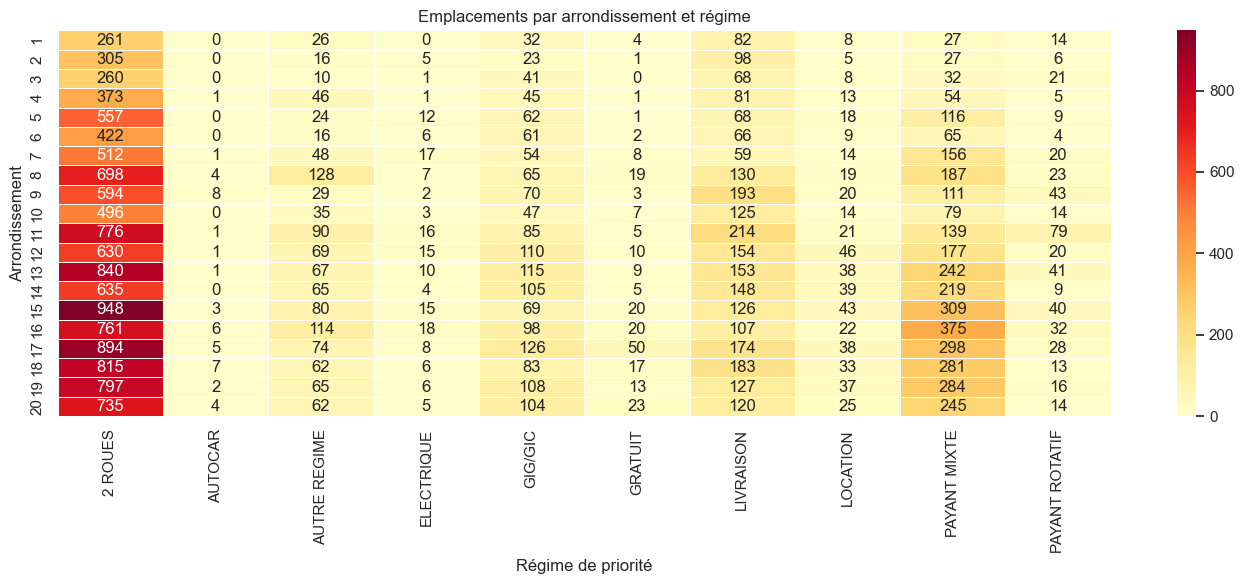

In [8]:
pivot = df.groupby(['arrond', 'regpri']).size().unstack(fill_value=0)

plt.figure(figsize=(14, 6))
sns.heatmap(pivot, cmap='YlOrRd', linewidths=0.5, annot=True, fmt='d')
plt.title('Emplacements par arrondissement et régime')
plt.xlabel('Régime de priorité')
plt.ylabel('Arrondissement')
plt.tight_layout()
plt.show()

## 8. Types de stationnement

typsta
Bataille        9897
Longitudinal    9666
Epi             2614
Name: count, dtype: int64


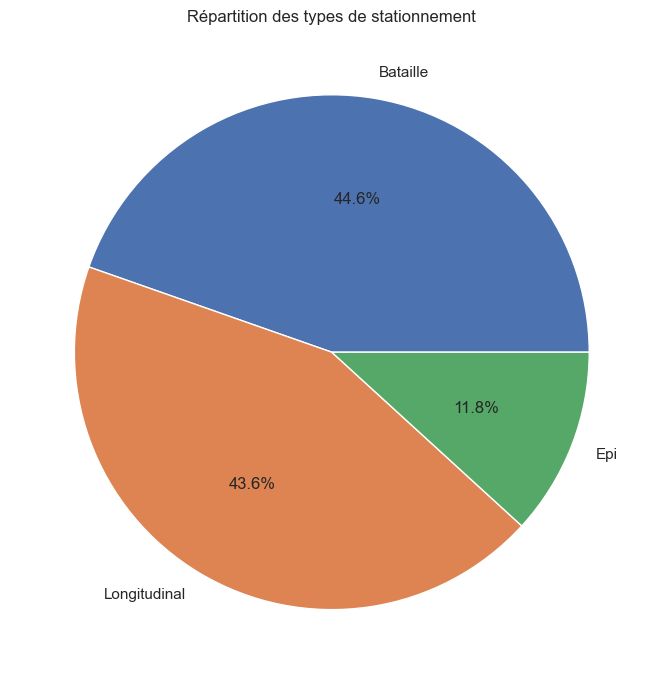

In [9]:
typsta_counts = df['typsta'].value_counts()
print(typsta_counts)

ax = typsta_counts.plot(kind='pie', autopct='%1.1f%%', figsize=(7, 7))
ax.set_title('Répartition des types de stationnement')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

## 9. Surface moyenne par régime

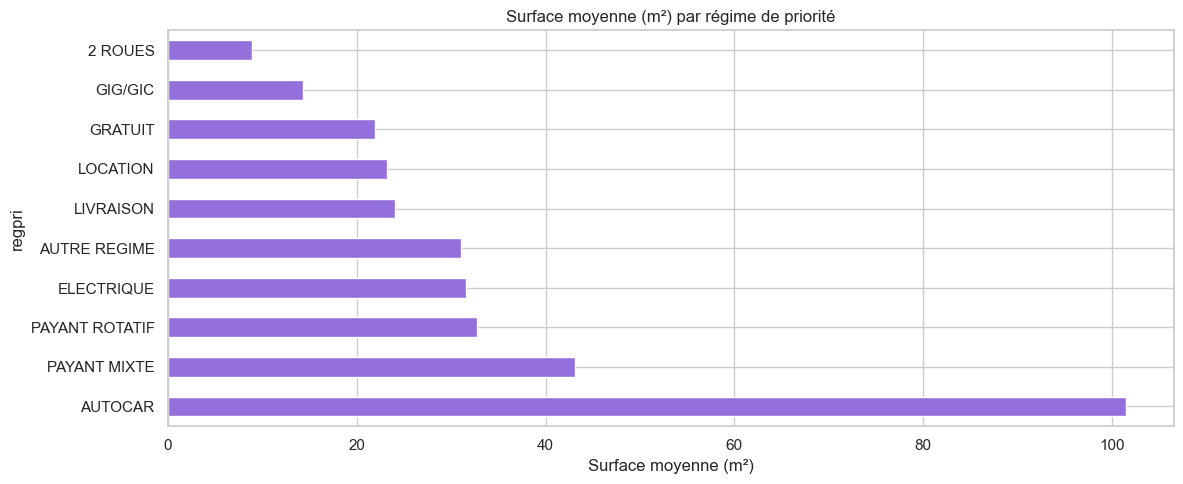

In [10]:
df['surface_calculee'] = pd.to_numeric(df['surface_calculee'], errors='coerce')

surface_regime = df.groupby('regpri')['surface_calculee'].mean().sort_values(ascending=False)
ax = surface_regime.plot(kind='barh', color='mediumpurple')
ax.set_title('Surface moyenne (m²) par régime de priorité')
ax.set_xlabel('Surface moyenne (m²)')
plt.tight_layout()
plt.show()

## 10. Synthèse

In [11]:
print('=== SYNTHÈSE EDA STATIONNEMENT ===')
print(f'Enregistrements bruts       : {len(df_raw):,}')
print(f'Doublons (sur id)           : {doublons:,}')
print(f'Enregistrements uniques     : {len(df):,}')
print(f'Arrondissements couverts    : {df["arrond"].nunique()}')
print(f'Régimes de priorité         : {df["regpri"].nunique()}')
print(f'Total places relevées       : {df["plarel"].sum():,.0f}')
print(f'Surface totale (m²)         : {df["surface_calculee"].sum():,.1f}')
print(f'\nArrondissement le + dense   : {int(df.groupby("arrond")["plarel"].sum().idxmax())}')
print(f'Arrondissement le - dense   : {int(df.groupby("arrond")["plarel"].sum().idxmin())}')

=== SYNTHÈSE EDA STATIONNEMENT ===
Enregistrements bruts       : 64,925
Doublons (sur id)           : 42,748
Enregistrements uniques     : 22,177
Arrondissements couverts    : 20
Régimes de priorité         : 10
Total places relevées       : 138,159
Surface totale (m²)         : 412,853.5

Arrondissement le + dense   : 15
Arrondissement le - dense   : 3
